# STANDARD: when does the buying stop?

An editable scenario notebook for **token-price tops, wallet-token exits, existing Charters, and buying additional branches**.

**Read the timing summary in section 4 after running all cells.** The defaults use a refreshed, pinned public-chain snapshot, observed two-hour/one-hour flows, and explicit behavioral assumptions. They produce a working conditional forecast, not a statistically calibrated probability of the market top.

Three quantities are kept separate:

1. **Peak time in each simulated path:** a hindsight statistic used to describe possible top windows.
2. **Best precommitted sale time:** maximizes average modeled cash across paths without knowing which path occurs.
3. **Best branch withdrawal time:** includes accrual, branch dilution/retirement, and resolution fees.

The model maximizes ETH. It does not forecast ETH/USD, sign transactions, or place trades. All monetary outputs are modeled proceeds, not wallet-specific executable quotes.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import sys, json, hashlib, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

candidates=[Path.cwd(),Path.cwd()/'research'/'standard-exit']
ROOT=next(p for p in candidates if (p/'model.py').exists() and (p/'notebook-evidence').exists())
sys.path.insert(0,str(ROOT))
import model as m
m.EVIDENCE=ROOT/'notebook-evidence'
OUT=ROOT/'notebook-results'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize':(11,4.5),'axes.grid':True,'grid.alpha':.2,'figure.dpi':110})
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.4f}')

# EDIT THESE: runs are deterministic for a given seed and configuration.
PATHS=200
POSITION_PATHS=80
HORIZON_DAYS=14
SEED=20260915
TOKEN_QUANTITY=100_000
TEN_BRANCH_COUNT=10
GAS_ETH_PER_EXIT=0.0  # set your estimate; fee/impact are already included

state=m.snapshot()
flows=m.observed_flows(state)
def liquidate(path,gross,charter=True,lp_fee=None,sell_tax=None):
    return m.liquidate(path,gross,charter,state['lp_fee'] if lp_fee is None else lp_fee,
                       state['sell_tax'] if sell_tax is None else sell_tax,state['liquidity_profile'])
home=m.read('home.json')
complete=m.read('collection-complete.json')
assert home['chainId']==4663
assert home['contracts']['standard'].lower()=='0x88ad8ddf1e3898412146a534538d418c6f8a9062'
assert home['blockHash']==complete['hash']
assert int(home['snapshot']['blockNumber'])==int(complete['block'])
assert 0<TOKEN_QUANTITY<state['float_tokens'] and PATHS>=2 and POSITION_PATHS>=2
snapshot_utc=pd.Timestamp(state['timestamp'],unit='s',tz='UTC')
snapshot_jst=snapshot_utc.tz_convert('Asia/Tokyo')
def at_jst(hours): return (snapshot_jst+pd.Timedelta(hours=float(hours))).strftime('%b %d %H:%M JST')

# EDIT if you know your balance; the default is an observed one-branch median.
OWN_PENDING_PER_BRANCH=state['own_pending']
state['own_pending']=OWN_PENDING_PER_BRANCH
assert 0<=OWN_PENDING_PER_BRANCH*TEN_BRANCH_COUNT<=state['pending']
display(Markdown(f'**Frozen observation:** {snapshot_utc} / **{snapshot_jst}**. '
                 f'Block **{complete["block"]}**, chain **4663**. '
                 'The notebook performs no live refresh when rerun.'))

**Frozen observation:** 2026-09-15 10:09:19+00:00 / **2026-09-15 19:09:19+09:00**. Block **63576310**, chain **4663**. The notebook performs no live refresh when rerun.

## 1. Starting numbers: observations versus assumptions

Pool balances, fees, branch counts and pending balances are read at one block. Future buyers and sellers are unknown. The wallet-float proxy subtracts the reconstructed pool token principal from total supply. It includes non-pool contract balances and is a turnover proxy, not a holder-level selling probability.

In [2]:
price0=state['eth']/state['token']
accrual=state['base_per_day']*state['multiplier']/state['branches']
starting=pd.DataFrame([
    ('Active branches',state['branches'],'chain getter'),
    ('Active Charters',state['active_charters'],'all issued IDs checked'),
    ('Actual pool ETH principal',state['available_eth'],'complete initialized tick reconstruction'),
    ('Protocol depth getter (comparison only)',state['protocol_depth_getter'],'not used as actual reserves'),
    ('Virtual ETH reserve',state['eth'],'active liquidity and sqrt price'),
    ('Virtual token reserve',state['token'],'active liquidity and sqrt price'),
    ('Outside-pool supply proxy',state['float_tokens'],'derived proxy'),
    ('STANDARD price in ETH',price0,'derived from pool sqrt price'),
    ('Issuance tokens/day',state['base_per_day']*state['multiplier'],'current policy'),
    ('Tokens/day per branch',accrual,'current issuance / branch count'),
    ('Representative branch balance',OWN_PENDING_PER_BRANCH,'observed median / editable'),
    ('Buy / sell hook tax, %',f'{state["buy_tax"]*100:.0f} / {state["sell_tax"]*100:.0f}','chain getters'),
    ('LP fee, %',state['lp_fee']*100,'pool getter'),
    ('Illustrative license floor',2*accrual,'two days of current output; future availability unknown'),
    ('Implied next auction opening',2*state['last_license_price'],'twice last sale; future settings may change'),
],columns=['Input','Value','Basis'])
display(starting)

flow_table=[]
for label,key in [('Two-hour window','full'),('Last hour','recent'),('Last ~15 minutes','last_bin')]:
    f=flows[key]
    flow_table.append(dict(window=label,gross_buy_ETH_hour=f['buy_eth_hour'],
        tokens_sold_day_equivalent=f['sell_tokens_day'],net_pool_ETH_hour=f['net_pool_eth_hour']))
display(pd.DataFrame(flow_table))

,Input,Value,Basis
0,Active branches,1099,chain getter
1,Active Charters,999,all issued IDs checked
2,Actual pool ETH principal,"3,352.8791",complete initialized tick reconstruction
3,Protocol depth getter (comparison only),"4,329.5758",not used as actual reserves
4,Virtual ETH reserve,"4,370.4644",active liquidity and sqrt price
5,Virtual token reserve,"23,631,977.3842",active liquidity and sqrt price
6,Outside-pool supply proxy,"74,724,461.0400",derived proxy
7,STANDARD price in ETH,0.0002,derived from pool sqrt price
8,Issuance tokens/day,"700,000.0000",current policy
9,Tokens/day per branch,636.9427,current issuance / branch count


,window,gross_buy_ETH_hour,tokens_sold_day_equivalent,net_pool_ETH_hour
0,Two-hour window,271.7032,"21,080,743.9901",127.3353
1,Last hour,448.0492,"7,631,145.1954",386.8236
2,Last ~15 minutes,565.2124,"4,378,557.6344",521.7627


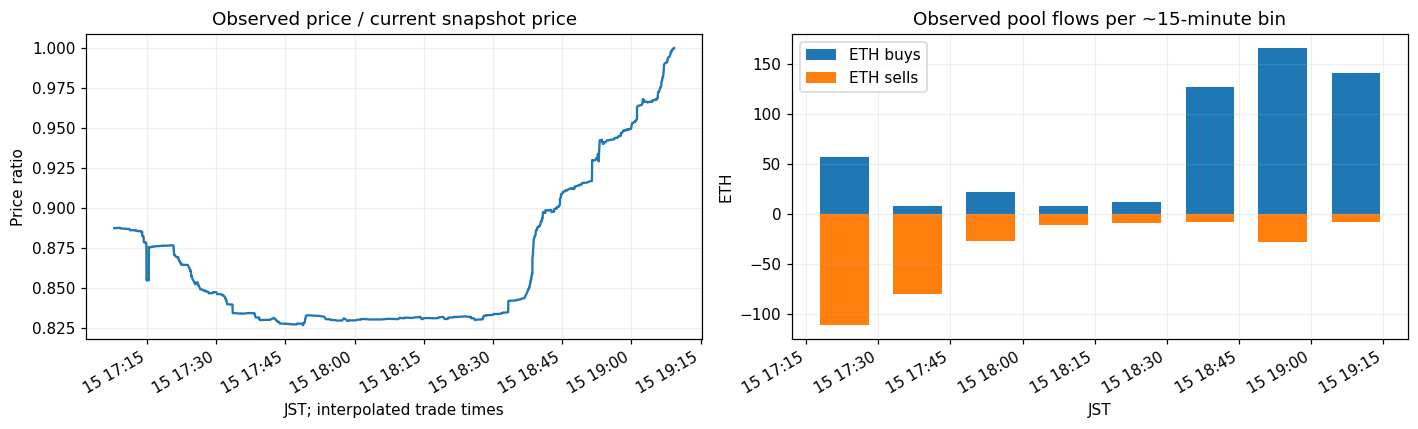

This window contains **1,426 swaps**. Its observed high is **1.000×** the snapshot price. This is **not** a verified all-time high.

In [3]:
# Exact block timestamps at bin boundaries; individual trade times are interpolated.
headers=m.read('swap-time-headers.json')
hb=np.array([int(x['number'],16) for x in headers])
ht=np.array([int(x['timestamp'],16) for x in headers])
logs=m.read('recent-swaps.json')['logs']
logs=sorted(logs,key=lambda x:(int(x['blockNumber'],16),int(x['logIndex'],16)))
trade_times=np.interp([int(x['blockNumber'],16) for x in logs],hb,ht)
trade_prices=np.array([(2**96/int(x['decoded']['sqrtPriceX96']))**2 for x in logs])
recent_peak=float(np.max(trade_prices))
observed=pd.DataFrame(flows['bins'])
observed['time']=pd.to_datetime(observed['end'],unit='s',utc=True).dt.tz_convert('Asia/Tokyo')
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(pd.to_datetime(trade_times,unit='s',utc=True).tz_convert('Asia/Tokyo'),trade_prices/price0)
axes[0].set(title='Observed price / current snapshot price',ylabel='Price ratio',xlabel='JST; interpolated trade times')
axes[1].bar(observed['time'],observed['buys_eth'],width=.007,label='ETH buys')
axes[1].bar(observed['time'],-observed['sells_eth'],width=.007,label='ETH sells')
axes[1].set(title='Observed pool flows per ~15-minute bin',ylabel='ETH',xlabel='JST')
axes[1].legend();fig.autofmt_xdate();fig.tight_layout()
fig.savefig(OUT/'observed-market.png',dpi=160);plt.show()
display(Markdown(f'This window contains **{len(logs):,} swaps**. Its observed high is '
                 f'**{recent_peak/price0:.3f}×** the snapshot price. This is **not** a verified all-time high.'))

### How the mechanism maps to the model

Wallet tokens earn nothing. A Charter's branches divide current issuance; earnings accrue in an internal ledger. Buying a license adds a branch and dilutes the others. Withdrawing mints the net ledger balance into wallet tokens and retires branches; those tokens can then be sold. Depositing alone adds no earning power. There is no universal scheduled unlock cliff here: withdrawals are owner decisions.

Buys move ETH into the pool and tokens out, raising ETH/token price. Speculative sales and withdrawn earnings sold into the pool lower it. Buying licenses with freshly purchased tokens creates market demand; using existing ledger earnings does not create that same ETH inflow. Withdrawals that are held rather than sold do not immediately move the AMM price. Issuance changes tomorrow's potential sales, not today's AMM price mechanically.

Your comparison is best written as

$$P_0 < E[G_t P_t],$$

where $G_t$ is the token-quantity multiplier. In general $E[G_tP_t] \ne E[G_t]E[P_t]$: larger issuance can coincide with a lower price. For a finite position, compare **net ETH proceeds after fees and price impact**, rather than spot value. This notebook does that jointly along each simulated path.

For a branch with balance $B(t)$ and net cash $C(t)$, the small-position approximation is $C(t)\approx B(t)(1-f(t))P(t)$. Waiting helps while the balance's growth rate exceeds the price decline and the worsening fee drag. Unlike fixed compounding, branch income also depends on everyone else's entry and retirement.

### Actual liquidity, held permanently in place

The protocol's locked LP is taken as safe. We reconstruct **all initialized ticks** and replay liquidity changes to identify positions, then verify their live balances at the snapshot. Current liquidity and both asset principals reconcile independently between ticks and positions.

**Locked liquidity is still traded liquidity:** ETH can leave through ordinary token sales. The active virtual reserve and the protocol's depth getter are not the amount of ETH principal actually present across ranges. The model uses the range reconstruction.

**66 initialized ticks; 54 live positions.** Actual principal: **3,352.88 ETH + 23,460,570 STANDARD**. Protocol-owned ETH principal treated as permanently safe: **3,340.98 ETH (99.65%)**. Other observed liquidity is held constant in these scenarios.

,tokens_sold,net_ETH,average_ETH_per_token,total_discount_to_spot
0,1000,0.1776,0.0002,0.0397
1,10000,1.7752,0.0002,0.0401
2,100000,17.6856,0.0002,0.0437
3,1000000,170.4557,0.0002,0.0783
4,5000000,734.2515,0.0001,0.2060
5,10000000,"1,251.6617",0.0001,0.3232
6,25000000,"2,165.8323",0.0001,0.5316
7,50000000,"2,861.0080",0.0001,0.6906


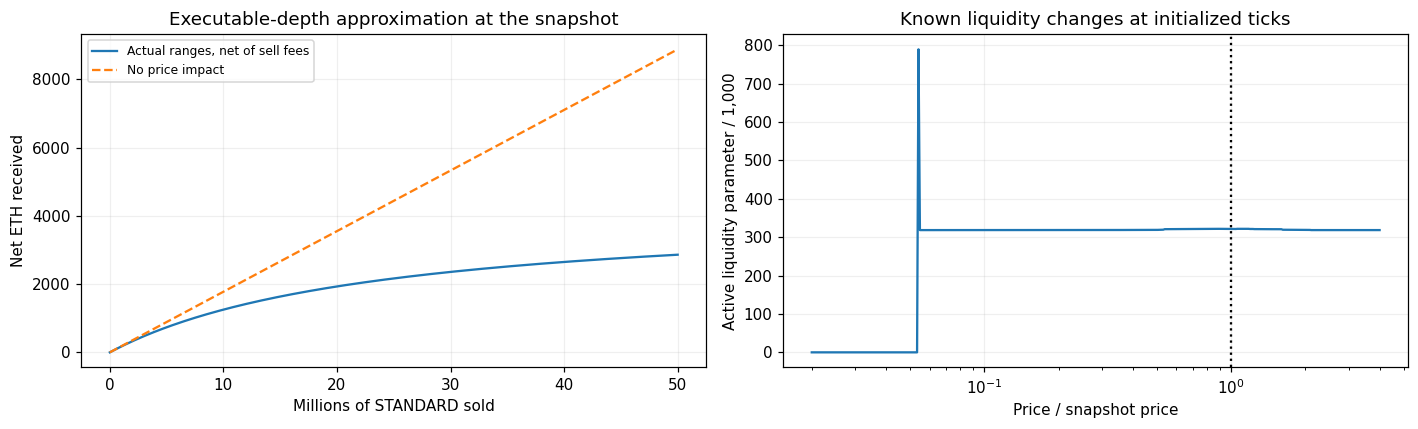

In [4]:
from liquidity import ConcentratedPool, LiquidityCurve
profile=state['liquidity_profile']
positions_evidence=m.read('liquidity-positions.json')
assert positions_evidence['blockHash']==complete['hash']
pool=ConcentratedPool(profile,state['lp_fee'],state['buy_tax'],state['sell_tax'])
assert np.isclose(pool.available_eth,positions_evidence['totalEthPrincipal'])
assert np.isclose(pool.real_tokens,positions_evidence['totalTokenPrincipal'])
locked_eth=positions_evidence['assumedPermanentEthPrincipal']
display(Markdown(f'**{len(profile["ticks"])} initialized ticks; {len(positions_evidence["positions"])} live positions.** '
 f'Actual principal: **{pool.available_eth:,.2f} ETH + {pool.real_tokens:,.0f} STANDARD**. '
 f'Protocol-owned ETH principal treated as permanently safe: **{locked_eth:,.2f} ETH '
 f'({locked_eth/pool.available_eth:.2%})**. Other observed liquidity is held constant in these scenarios.'))
depth=[]
for quantity in [1_000,10_000,100_000,1_000_000,5_000_000,10_000_000,25_000_000,50_000_000]:
    net=pool.quote_sell(quantity)
    depth.append(dict(tokens_sold=quantity,net_ETH=net,average_ETH_per_token=net/quantity,
        total_discount_to_spot=1-net/(quantity*pool.price)))
depth_table=pd.DataFrame(depth);display(depth_table)
depth_table.to_csv(OUT/'liquidity-depth.csv',index=False)
quantities=np.linspace(0,50_000_000,300)
proceeds=np.array([pool.quote_sell(q) for q in quantities])
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(quantities/1e6,proceeds,label='Actual ranges, net of sell fees')
axes[0].plot(quantities/1e6,quantities*pool.price*.99*.97,ls='--',label='No price impact')
axes[0].set(xlabel='Millions of STANDARD sold',ylabel='Net ETH received',title='Executable-depth approximation at the snapshot');axes[0].legend(fontsize=8)
curve=pool.curve
price_ratios=np.geomspace(.02,4,400)
sqrts=pool.sqrt/np.sqrt(price_ratios)
liquidities=curve.L[curve.index(sqrts)]
axes[1].plot(price_ratios,liquidities/1e3)
axes[1].axvline(1,color='black',ls=':')
axes[1].set(xscale='log',xlabel='Price / snapshot price',ylabel='Active liquidity parameter / 1,000',title='Known liquidity changes at initialized ticks')
fig.tight_layout();fig.savefig(OUT/'liquidity-depth.png',dpi=160);plt.show()

## 2. Editable scenarios

The central case blends the longer window with the recent rebound. This avoids treating one buying burst as a permanent demand rate.

- **Fast fade:** two-hour buying/selling proxies; buying halves in six hours.
- **Central case:** a 50/50 blend of the two-hour and last-hour proxies; buying halves in 24 hours.
- **Continued rebound:** last-hour buying/selling proxies; buying halves in 72 hours.
- **Withdrawal-wave stress:** central demand, with a hypothetical 50% branch withdrawal at hour 48. This is not a known unlock event.

The **30% / 50% / 20% weights are subjective working priors, not estimated likelihoods**. The stress case gets no weight in the main mixture. Change the numbers below to express a different view.

`sell_hazard_day` is a turnover proxy: the daily fraction sold is `1 − exp(−hazard)`. It does not identify the probability that a particular wallet sells. Branch exit hazards, returned-token selling fractions and license uptake are scenario assumptions.

In [5]:
full,recent=flows['full'],flows['recent']
full_sell=full['sell_tokens_day']/state['float_tokens']
recent_sell=recent['sell_tokens_day']/state['float_tokens']

# EDIT: the most consequential cells in the notebook.
scenario_inputs=pd.DataFrame([
 dict(name='Fast fade',weight=.30,buy_eth_hour=full['buy_eth_hour'],demand_half_life_hours=6,
      sell_hazard_day=full_sell,exit_hazard_day=.04,exit_drawdown_sensitivity=.50,license_demand_day=25),
 dict(name='Central case',weight=.50,buy_eth_hour=.5*(full['buy_eth_hour']+recent['buy_eth_hour']),demand_half_life_hours=24,
      sell_hazard_day=.5*(full_sell+recent_sell),exit_hazard_day=.02,exit_drawdown_sensitivity=.30,license_demand_day=60),
 dict(name='Continued rebound',weight=.20,buy_eth_hour=recent['buy_eth_hour'],demand_half_life_hours=72,
      sell_hazard_day=recent_sell,exit_hazard_day=.01,exit_drawdown_sensitivity=.15,license_demand_day=100),
 dict(name='Withdrawal wave (stress)',weight=0.,buy_eth_hour=.5*(full['buy_eth_hour']+recent['buy_eth_hour']),demand_half_life_hours=24,
      sell_hazard_day=.005,exit_hazard_day=.005,exit_drawdown_sensitivity=.05,license_demand_day=60),
])
# Stress keeps the central speculative-selling proxy; only branch exits change.
scenario_inputs.loc[3,'sell_hazard_day']=scenario_inputs.loc[1,'sell_hazard_day']
assert np.isclose(scenario_inputs.weight.sum(),1) and (scenario_inputs.weight>=0).all()
scenarios={}
for row in scenario_inputs.to_dict('records'):
    weight=row.pop('weight')
    extra={'coordinated_exit_hour':48} if row['name']=='Withdrawal wave (stress)' else {}
    scenarios[row['name']]=m.Scenario(**row,external_license_fraction=.25,
                                     returned_sell_fraction=.90,buybacks_enabled=False,**extra)
weights=dict(zip(scenario_inputs.name,scenario_inputs.weight))
display(scenario_inputs)
display(Markdown('The main runs assume no automatic buyback execution. The saved vault funds exist, '
                 'but future execution is not assumed. You can set `buybacks_enabled=True` to test the defense case.'))

,name,weight,buy_eth_hour,demand_half_life_hours,sell_hazard_day,exit_hazard_day,exit_drawdown_sensitivity,license_demand_day
0,Fast fade,0.3000,271.7032,6,0.2821,0.0400,0.5000,25
1,Central case,0.5000,359.8762,24,0.1921,0.0200,0.3000,60
2,Continued rebound,0.2000,448.0492,72,0.1021,0.0100,0.1500,100
3,Withdrawal wave (stress),0.0000,359.8762,24,0.1921,0.0050,0.0500,60


The main runs assume no automatic buyback execution. The saved vault funds exist, but future execution is not assumed. You can set `buybacks_enabled=True` to test the defense case.

## 3. Simulate market paths

The same random seeds are used across scenarios so changes in assumptions are easier to compare. The core model varies initial buying, its decay, selling/withdrawal hazards, and serially correlated buying intensity. These distributions are illustrative, not fitted confidence intervals.

Fees, own-position price impact, ledger issuance, branch retirement and dilution are included. The pool model walks the observed initialized ticks, preserving each range. Protocol-owned liquidity is assumed permanently locked and safe, as requested. Other observed liquidity also stays in place in the baseline; no future removal or new LP additions are assumed. Fees are excluded from principal, as in v4. This does not fix price: swaps still exchange the locked ETH for tokens.

In [6]:
market={}
for name,scenario in scenarios.items():
    market[name]=np.stack([m.simulate(state,scenario,SEED+j,HORIZON_DAYS,
        protected_branches=0,owned_wallet_tokens=TOKEN_QUANTITY) for j in range(PATHS)])
hours=market['Central case'][0,:,0]
assert all(np.isfinite(x).all() for x in market.values())
print(f'{len(scenarios)} scenarios × {PATHS} paths × {len(hours)} hourly observations')

4 scenarios × 200 paths × 337 hourly observations


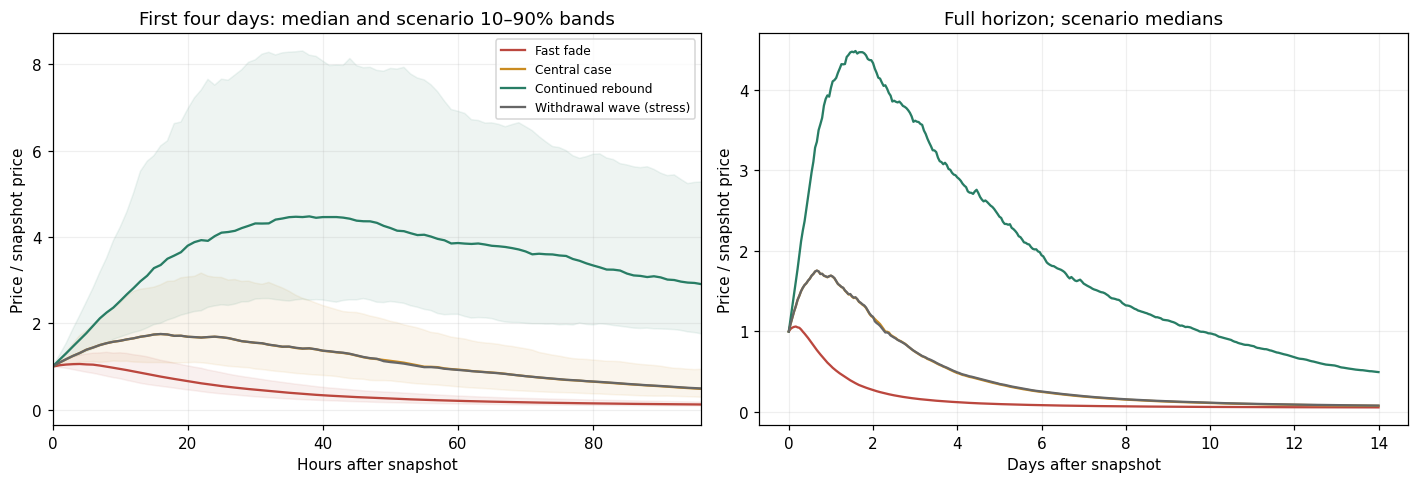

In [7]:
colors={'Fast fade':'#bb473e','Central case':'#ca8b20','Continued rebound':'#287d65','Withdrawal wave (stress)':'#666666'}
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for name,path in market.items():
    price=path[:,:,4]/price0
    axes[0].plot(hours,np.median(price,axis=0),label=name,color=colors[name])
    if weights[name]>0:
        axes[0].fill_between(hours,np.quantile(price,.1,axis=0),np.quantile(price,.9,axis=0),alpha=.08,color=colors[name])
    axes[1].plot(hours/24,np.median(price,axis=0),label=name,color=colors[name])
axes[0].set(xlim=(0,96),xlabel='Hours after snapshot',ylabel='Price / snapshot price',title='First four days: median and scenario 10–90% bands')
axes[1].set(xlabel='Days after snapshot',ylabel='Price / snapshot price',title='Full horizon; scenario medians')
axes[0].legend(fontsize=8);fig.tight_layout()
fig.savefig(OUT/'price-scenarios.png',dpi=160);plt.show()

## 4. When is the most likely top under these assumptions?

The table gives both hindsight path-peak timing and the best sale date chosen **before knowing the path**. A future-path maximum at hour zero means “no modeled improvement over the snapshot”; it does not prove the all-time top has already happened.

The central case is the working forecast. The weighted distribution is a sensitivity calculation under the editable priors above. Unequal-width buckets show probability mass; their mode depends on bin widths. We also report the densest equal-width six-hour window. Neither identifies an exact execution time.

,scenario,weight,median_path_peak_h,p10_peak_h,p90_peak_h,peak_of_mean_price_h,best_precommitted_sale_h,best_sale_JST,mean_net_ETH_at_best,snapshot_is_future_max_fraction,final_hour_peak_fraction,recent_observed_high_not_exceeded_fraction
0,Fast fade,0.3000,3.0000,0.0000,8.1000,4.0000,4.0000,Sep 15 23:09 JST,18.9821,0.1900,0.0000,0.1900
1,Central case,0.5000,19.0000,8.0000,32.0000,19.0000,19.0000,Sep 16 14:09 JST,33.8193,0.0000,0.0000,0.0000
2,Continued rebound,0.2000,37.5000,22.0000,72.2000,35.0000,35.0000,Sep 17 06:09 JST,87.2680,0.0000,0.0000,0.0000
3,Withdrawal wave (stress),0.0000,19.0000,8.0000,32.0000,19.0000,19.0000,Sep 16 14:09 JST,33.8494,0.0000,0.0000,0.0000


## Working timing estimate

**Central case:** median simulated price top at **+19 hours** (**Sep 16 14:09 JST**). Its scenario 10–90% timing range is **+8 to +32 hours**.

With the **subjective** weights shown above, the highest-mass peak bucket is **0–6 h** (18.9% of the weighted simulated paths). The densest equal-width six-hour window is **0–6 h** (18.8%); the point mass at the snapshot is 5.7%. The mixture's best precommitted sale is **+23 hours**, **Sep 16 18:09 JST**.

These are conditional model outputs. The priors and behavioral parameters are not empirically estimated probabilities. Changing demand persistence or selling behavior can move the top substantially.

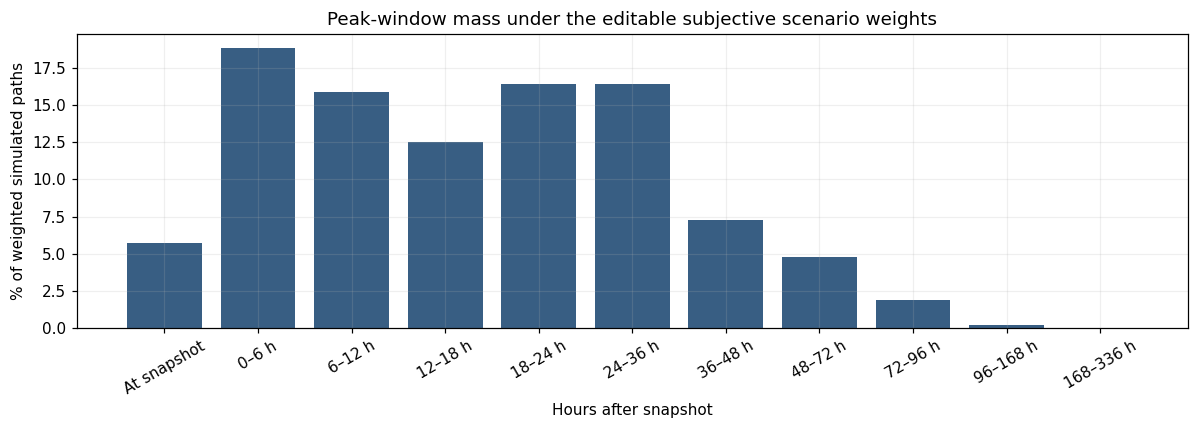

In [8]:
peak_rows=[];peak_hours={};sale_curves={}
for name,path in market.items():
    price=path[:,:,4]
    ph=hours[np.argmax(price,axis=1)];peak_hours[name]=ph
    cash=np.stack([liquidate(p,TOKEN_QUANTITY,False,state['lp_fee'],state['sell_tax']) for p in path])-GAS_ETH_PER_EXIT
    sale_curves[name]=cash
    best=int(np.argmax(cash.mean(axis=0)))
    peak_rows.append(dict(scenario=name,weight=weights[name],
        median_path_peak_h=float(np.median(ph)),p10_peak_h=float(np.quantile(ph,.1)),p90_peak_h=float(np.quantile(ph,.9)),
        peak_of_mean_price_h=float(hours[np.argmax(price.mean(axis=0))]),
        best_precommitted_sale_h=float(hours[best]),best_sale_JST=at_jst(hours[best]),
        mean_net_ETH_at_best=float(cash[:,best].mean()),
        snapshot_is_future_max_fraction=float(np.mean(ph==0)),
        final_hour_peak_fraction=float(np.mean(ph==hours[-1])),
        recent_observed_high_not_exceeded_fraction=float(np.mean(price.max(axis=1)<=recent_peak))))
peak_summary=pd.DataFrame(peak_rows)
display(peak_summary)

edges=np.array([0,6,12,18,24,36,48,72,96,168,HORIZON_DAYS*24],dtype=float)
edges=np.unique(edges[(edges>=0)&(edges<=hours[-1])])
labels=['At snapshot']+[f'{a:g}–{b:g} h' for a,b in zip(edges,edges[1:])]
mass={}
for name,ph in peak_hours.items():
    mass[name]=np.r_[np.sum(ph==0),np.histogram(ph[ph>0],bins=edges)[0]]/len(ph)
    assert np.isclose(mass[name].sum(),1)
weighted_mass=sum(weights[n]*mass[n] for n in scenarios)
weighted_cash=sum(weights[n]*sale_curves[n].mean(axis=0) for n in scenarios)
weighted_best=float(hours[np.argmax(weighted_cash)])
mode_idx=int(np.argmax(weighted_mass));modal_window=labels[mode_idx]
six_edges=np.arange(0,hours[-1]+6.01,6)
six_mass=sum(weights[n]*np.histogram(peak_hours[n][peak_hours[n]>0],bins=six_edges)[0]/PATHS for n in scenarios)
six_mode=int(np.argmax(six_mass)); six_window=f'{six_edges[six_mode]:g}–{six_edges[six_mode+1]:g} h'
central=peak_summary.set_index('scenario').loc['Central case']
summary_text=(f'## Working timing estimate\n\n'
 f'**Central case:** median simulated price top at **+{central.median_path_peak_h:.0f} hours** '
 f'(**{at_jst(central.median_path_peak_h)}**). Its scenario 10–90% timing range is '
 f'**+{central.p10_peak_h:.0f} to +{central.p90_peak_h:.0f} hours**.\n\n'
 f'With the **subjective** weights shown above, the highest-mass peak bucket is '
 f'**{modal_window}** ({weighted_mass[mode_idx]:.1%} of the weighted simulated paths). '
 f'The densest equal-width six-hour window is **{six_window}** ({six_mass[six_mode]:.1%}); '
 f'the point mass at the snapshot is {weighted_mass[0]:.1%}. '
 f'The mixture\'s best precommitted sale is **+{weighted_best:.0f} hours**, '
 f'**{at_jst(weighted_best)}**.\n\n'
 f'These are conditional model outputs. The priors and behavioral parameters are not empirically estimated '
 f'probabilities. Changing demand persistence or selling behavior can move the top substantially.')
display(Markdown(summary_text))
(OUT/'timing-summary.md').write_text(summary_text)

fig,ax=plt.subplots(figsize=(11,4))
ax.bar(labels,weighted_mass*100,color='#385e83')
ax.set(title='Peak-window mass under the editable subjective scenario weights',ylabel='% of weighted simulated paths',xlabel='Hours after snapshot')
ax.tick_params(axis='x',rotation=30);fig.tight_layout()
fig.savefig(OUT/'top-window.png',dpi=160);plt.show()

### How much of the answer comes from the prior weights?

These alternative mixtures are judgments, not new evidence. If their preferred sale times differ greatly, a precise combined forecast would mostly reflect how the scenarios were weighted.

In [9]:
prior_sets={'Cautious':[.50,.35,.15],'Working':[.30,.50,.20],'Rebound conviction':[.15,.45,.40]}
mixtures=[]
names=['Fast fade','Central case','Continued rebound']
for label,ws in prior_sets.items():
    curve=sum(w*sale_curves[n].mean(axis=0) for w,n in zip(ws,names))
    pm=sum(w*mass[n] for w,n in zip(ws,names))
    best=float(hours[np.argmax(curve)])
    mixtures.append(dict(prior=label,weights=ws,best_sale_h=best,JST=at_jst(best),modal_peak_bucket=labels[np.argmax(pm)]))
display(pd.DataFrame(mixtures))

,prior,weights,best_sale_h,JST,modal_peak_bucket
0,Cautious,"[0.5, 0.35, 0.15]",20.0000,Sep 16 15:09 JST,0–6 h
1,Working,"[0.3, 0.5, 0.2]",23.0000,Sep 16 18:09 JST,0–6 h
2,Rebound conviction,"[0.15, 0.45, 0.4]",30.0000,Sep 17 01:09 JST,24–36 h


### Timing precision and simulation sampling error

A broad, nearly flat proceeds curve is more useful than a single maximizing hour. The table reports the hours within 1% of each scenario's maximum mean proceeds and a bootstrap range for the maximizing hour. Bootstrap resampling measures Monte Carlo variation under this model; it does **not** measure uncertainty about the behavioral assumptions or the real market.

In [10]:
precision=[];bootstrap_rng=np.random.default_rng(SEED+888)
for name,cash in sale_curves.items():
    mean=cash.mean(axis=0);near=hours[mean>=.99*mean.max()]
    bests=[]
    for _ in range(200):
        sample=cash[bootstrap_rng.integers(0,len(cash),len(cash))]
        bests.append(hours[np.argmax(sample.mean(axis=0))])
    precision.append(dict(scenario=name,within_1pct_first_h=float(near.min()),within_1pct_last_h=float(near.max()),
        bootstrap_p10_best_h=float(np.quantile(bests,.1)),bootstrap_p90_best_h=float(np.quantile(bests,.9))))
precision_table=pd.DataFrame(precision);display(precision_table)
precision_table.to_csv(OUT/'timing-precision.csv',index=False)

,scenario,within_1pct_first_h,within_1pct_last_h,bootstrap_p10_best_h,bootstrap_p90_best_h
0,Fast fade,3.0000,5.0000,4.0000,4.0000
1,Central case,16.0000,22.0000,18.0000,20.0000
2,Continued rebound,31.0000,40.0000,33.0000,38.0000
3,Withdrawal wave (stress),16.0000,22.0000,17.9000,20.0000


### Wallet size and downside

These cases each exclude the owner's entire quantity from the crowd's selling stock, then quote a full exit across the observed ranges. The chosen hour maximizes mean ETH before the future path is known. The downside column compares that fixed-hour sale with selling the same quantity immediately. It is conditional on the assumed scenario and excludes ETH/USD changes.

In [11]:
wallet_risk=[]
for name,scenario in scenarios.items():
    for quantity in [10_000,100_000,1_000_000]:
        if quantity==TOKEN_QUANTITY:
            cash=sale_curves[name]
        else:
            ps=[m.simulate(state,scenario,SEED+j,HORIZON_DAYS,protected_branches=0,
                          owned_wallet_tokens=quantity) for j in range(POSITION_PATHS)]
            cash=np.stack([liquidate(p,quantity,False) for p in ps])-GAS_ETH_PER_EXIT
        best=int(np.argmax(cash.mean(axis=0)));now=float(cash[0,0]);terminal=cash[:,best]
        wallet_risk.append(dict(scenario=name,quantity=quantity,best_h=float(hours[best]),now_ETH=now,
            mean_ETH=float(terminal.mean()),p10_ETH=float(np.quantile(terminal,.1)),p90_ETH=float(np.quantile(terminal,.9)),
            fraction_below_selling_now=float(np.mean(terminal<now)),mean_return_vs_now=float(terminal.mean()/now-1)))
wallet_risk_table=pd.DataFrame(wallet_risk);display(wallet_risk_table)
wallet_risk_table.to_csv(OUT/'wallet-risk-reward.csv',index=False)

,scenario,quantity,best_h,now_ETH,mean_ETH,p10_ETH,p90_ETH,fraction_below_selling_now,mean_return_vs_now
0,Fast fade,10000,4.0000,1.7752,1.9052,1.5733,2.2401,0.3125,0.0732
1,Fast fade,100000,4.0000,17.6856,18.9821,15.9493,22.3642,0.3400,0.0733
2,Fast fade,1000000,4.0000,170.4557,183.2027,152.0761,214.6836,0.3125,0.0748
3,Central case,10000,20.0000,1.7752,3.4070,1.8532,5.1916,0.0750,0.9192
4,Central case,100000,19.0000,17.6856,33.8193,19.2506,53.9035,0.0550,0.9123
5,Central case,1000000,20.0000,170.4557,323.4022,179.3964,488.4654,0.0625,0.8973
6,Continued rebound,10000,35.0000,1.7752,8.8959,4.2584,14.4172,0.0000,4.0111
7,Continued rebound,100000,35.0000,17.6856,87.2680,44.4484,145.3776,0.0000,3.9344
8,Continued rebound,1000000,35.0000,170.4557,813.8542,403.9736,"1,298.6915",0.0000,3.7746
9,Withdrawal wave (stress),10000,20.0000,1.7752,3.4102,1.8556,5.1947,0.0750,0.9210


## 5. Existing branches, new branches, and reinvestment

The user's own branches are protected from the crowd's retirement hazard while they wait. They remain in the issuance denominator. Ten-branch positions use ten times the editable representative starting balance, not an actual user's Charter.

External expansion is measured as **additional net ETH versus retaining the original branch and withdrawing at the same time**, after paying for the purchased tokens. Internal reinvestment is measured as total final proceeds; compare it with the existing-branch curve. It includes the choice to sell before enough earnings accrue to buy a license.

Floor-price entry is a hypothetical availability case: today's licenses are sold out, and future auction prices depend on other participants. The high-price case uses twice the last observed sale price. These are comparison cases, not live executable offers.

In [12]:
positions={};position_rows=[];participation={}
for name,scenario in scenarios.items():
    base_paths=[m.simulate(state,scenario,SEED+j,HORIZON_DAYS,protected_branches=1) for j in range(POSITION_PATHS)]
    base=np.stack([liquidate(p,p[:,11],lp_fee=state['lp_fee'],sell_tax=state['sell_tax']) for p in base_paths])-GAS_ETH_PER_EXIT
    vals={'Existing one branch':base}
    ten=[m.simulate(state,scenario,SEED+j,HORIZON_DAYS,protected_branches=TEN_BRANCH_COUNT) for j in range(POSITION_PATHS)]
    vals[f'Existing {TEN_BRANCH_COUNT} branches']=np.stack([liquidate(p,p[:,11],lp_fee=state['lp_fee'],sell_tax=state['sell_tax']) for p in ten])-GAS_ETH_PER_EXIT
    for label,cost,internal in [
        ('External: next opening price',2*state['last_license_price'],False),
        ('External: floor if available',2*accrual,False),
        ('Reinvest: floor if available',2*accrual,True)]:
        curves=[];funding=[]
        for j in range(POSITION_PATHS):
            p=m.simulate(state,scenario,SEED+j,HORIZON_DAYS,expansion_cost=cost,internal_expansion=internal)
            cash=liquidate(p,p[:,11],lp_fee=state['lp_fee'],sell_tax=state['sell_tax'])-p[:,12]-GAS_ETH_PER_EXIT
            if not internal:
                cash-=base[j]
                cash[p[:,13]==0]=np.nan
            curves.append(cash);funding.append(p[:,12])
        vals[label]=np.stack(curves)
        if label=='External: floor if available':
            participation[name]={'incremental_net':np.stack(curves),'funding_cost':np.stack(funding)}
    positions[name]=vals
    for label,arr in vals.items():
        valid=np.isfinite(arr).all(axis=0)
        mean=np.full(len(hours),np.nan);mean[valid]=arr[:,valid].mean(axis=0)
        best=int(np.nanargmax(mean))
        position_rows.append(dict(scenario=name,position=label,best_h=float(hours[best]),
            mean_ETH=float(mean[best]),p10_ETH=float(np.quantile(arr[:,best],.1)),p90_ETH=float(np.quantile(arr[:,best],.9)),
            boundary_optimum=bool(best==len(hours)-1),
            measure='incremental net ETH' if label.startswith('External:') else 'total net ETH'))
position_summary=pd.DataFrame(position_rows)
display(position_summary)

,scenario,position,best_h,mean_ETH,p10_ETH,p90_ETH,boundary_optimum,measure
0,Fast fade,Existing one branch,336.0000,0.4768,0.4506,0.5102,True,total net ETH
1,Fast fade,Existing 10 branches,336.0000,4.1731,3.9655,4.4574,True,total net ETH
2,Fast fade,External: next opening price,336.0000,-3.3092,-4.9570,-2.0939,True,incremental net ETH
3,Fast fade,External: floor if available,336.0000,0.2571,0.1601,0.3290,True,incremental net ETH
4,Fast fade,Reinvest: floor if available,336.0000,0.9275,0.8767,0.9921,True,total net ETH
5,Central case,Existing one branch,44.0000,0.3379,0.1699,0.5353,False,total net ETH
6,Central case,Existing 10 branches,44.0000,3.3703,1.6945,5.3406,False,total net ETH
7,Central case,External: next opening price,56.0000,-8.2726,-13.0572,-4.8228,False,incremental net ETH
8,Central case,External: floor if available,56.0000,-0.2505,-0.4203,-0.1326,False,incremental net ETH
9,Central case,Reinvest: floor if available,38.0000,0.3356,0.1604,0.5546,False,total net ETH


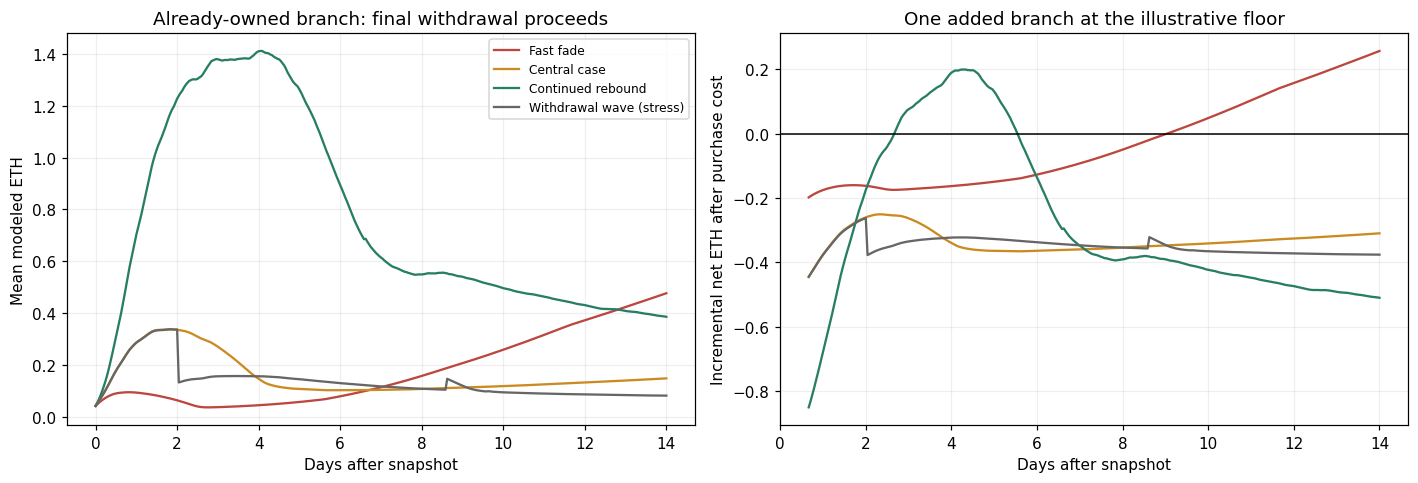

**Boundary optima are unresolved.** A branch curve still rising at day 14 does not identify day 14 as the best withdrawal date. Late gains often depend on competitors continuing to retire branches while you retain your share; this is not a solved strategic equilibrium.

In [13]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for name,vals in positions.items():
    axes[0].plot(hours/24,vals['Existing one branch'].mean(axis=0),label=name,color=colors[name])
    arr=vals['External: floor if available'];valid=np.isfinite(arr).all(axis=0)
    axes[1].plot(hours[valid]/24,arr[:,valid].mean(axis=0),label=name,color=colors[name])
axes[0].set(title='Already-owned branch: final withdrawal proceeds',xlabel='Days after snapshot',ylabel='Mean modeled ETH')
axes[1].set(title='One added branch at the illustrative floor',xlabel='Days after snapshot',ylabel='Incremental net ETH after purchase cost')
axes[1].axhline(0,color='black',lw=1);axes[0].legend(fontsize=8);fig.tight_layout()
fig.savefig(OUT/'branch-comparison.png',dpi=160);plt.show()
display(Markdown('**Boundary optima are unresolved.** A branch curve still rising at day 14 does not '
 'identify day 14 as the best withdrawal date. Late gains often depend on competitors continuing to retire '
 'branches while you retain your share; this is not a solved strategic equilibrium.'))

## 6. Sensitivity: which assumptions move the top?

The heatmap varies buying persistence and the initial buy/sell flow ratio. Other inputs use the central case. Each cell uses the same 20 random seeds and reports the peak of its **mean price curve** over seven days. This is a sensitivity experiment, not a likelihood map.

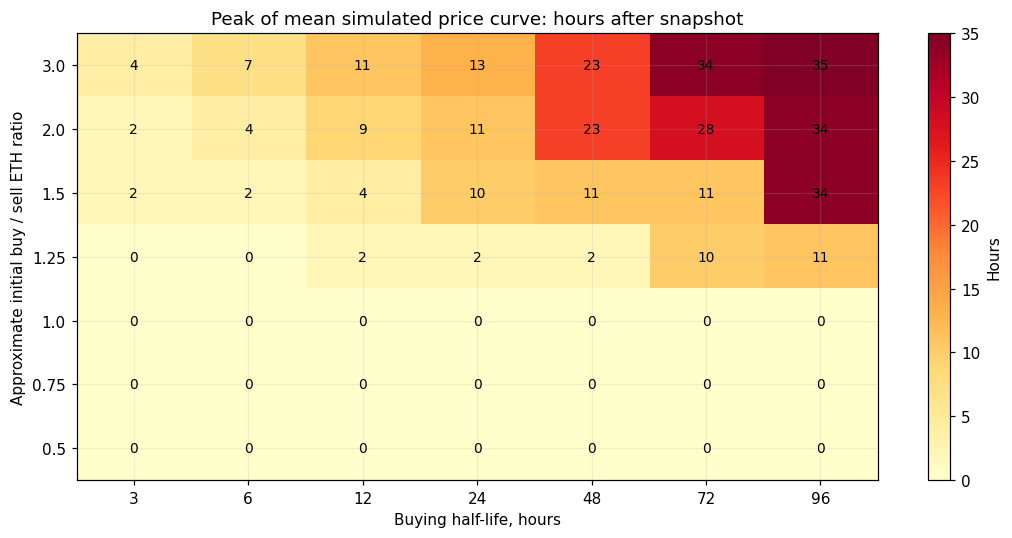

In [14]:
half_lives=[3,6,12,24,48,72,96]
ratios=[.5,.75,1.,1.25,1.5,2.,3.]
sell_eth_hour=sum(x['sells_eth'] for x in flows['bins'])/flows['full']['hours']
heat=np.zeros((len(ratios),len(half_lives)))
central_scenario=scenarios['Central case']
for i,ratio in enumerate(ratios):
    for j,half_life in enumerate(half_lives):
        params=vars(central_scenario).copy()
        # Convert approximate token sales at the snapshot price to gross ETH
        # buying needed for the displayed starting ratio, before future impact.
        central_sell_eth=(central_scenario.sell_hazard_day*state['float_tokens']/24)*price0*(1-state['lp_fee'])
        params.update(name='sensitivity',buy_eth_hour=ratio*central_sell_eth/(1-state['buy_tax'])/(1-state['lp_fee']),demand_half_life_hours=half_life)
        paths=np.stack([m.simulate(state,m.Scenario(**params),SEED+k,days=7,protected_branches=0,owned_wallet_tokens=TOKEN_QUANTITY) for k in range(20)])
        heat[i,j]=paths[0,np.argmax(paths[:,:,4].mean(axis=0)),0]
fig,ax=plt.subplots(figsize=(10,5))
im=ax.imshow(heat,origin='lower',aspect='auto',cmap='YlOrRd')
ax.set_xticks(range(len(half_lives)),half_lives);ax.set_yticks(range(len(ratios)),ratios)
ax.set(xlabel='Buying half-life, hours',ylabel='Approximate initial buy / sell ETH ratio',title='Peak of mean simulated price curve: hours after snapshot')
for i in range(len(ratios)):
    for j in range(len(half_lives)):ax.text(j,i,f'{heat[i,j]:.0f}',ha='center',va='center',fontsize=9)
fig.colorbar(im,ax=ax,label='Hours');fig.tight_layout()
fig.savefig(OUT/'top-sensitivity.png',dpi=160);plt.show()

## 7. Simple branch break-even checks

For constant branch income $a$, existing balance $B_0$, constant fee, and an assumed exponential price decline with half-life $h$:

$$C(t)\propto(B_0+at)e^{-(\ln 2)t/h},\qquad t^*=\max(0,h/\ln2-B_0/a).$$

This benchmark excludes branch dilution, survivor effects and changing fees. It makes clear why a price-decline assumption is necessary to produce a withdrawal date.

A new branch paid for with $c$ tokens has to recover its entry cost. In the same simplified model, the largest discounted harvest is roughly $(1-f)a/(e\lambda)$. A two-day gross-output license therefore needs roughly four days of price half-life even before market purchase/sale frictions. A high auction premium needs much longer.

In [15]:
display(pd.DataFrame(m.analytic_grid(state)))
license_checks=[]
for label,cost in [('Illustrative floor',2*accrual),('Implied next opening',2*state['last_license_price'])]:
    license_checks.append(dict(entry=label,cost_tokens=cost,gross_output_days=cost/accrual,
        minimum_price_half_life_days_simplified=cost*math.e*math.log(2)/(.98*accrual)))
display(pd.DataFrame(license_checks))

,price_half_life_days,one_branch_best_hours,max_license_tokens_constant_fee
0,0.2500,0.0000,82.8221
1,0.5000,8.1581,165.6443
2,1.0000,25.4704,331.2886
3,2.0000,60.0951,662.5772
4,4.0000,129.3444,"1,325.1544"
5,7.0000,233.2185,"2,319.0201"
6,14.0000,475.5913,"4,638.0403"


,entry,cost_tokens,gross_output_days,minimum_price_half_life_days_simplified
0,Illustrative floor,"1,273.8854",2.0000,3.8452
1,Implied next opening,"23,776.6819",37.3294,71.7703


## 8. Other people's branches and model limits

The native `deposit`, `buyLicenses`, and `withdraw` probes from a non-owner returned `NotCharterOwner`. This notebook does not invent a return stream for funding another owner. A wrapper or separate ownership agreement would need its own rules for payouts, control and exit.

Holding wallet tokens provides no branch issuance. Depositing without adding a branch increases the internal balance but does not increase the issuance share. Existing Charters and new branches therefore need different opportunity-cost comparisons.

**The estimate changes if:** buying is sustained longer, large holders sell faster, license demand weakens, branches exit together, new liquidity arrives, or actual buybacks begin. Hourly model peaks are not precise execution deadlines. Future LP additions, complete deployed-contract behavior, gas variation and ETH/USD risk are not fully modeled. The empirical history is short; no out-of-sample predictive performance is established.

Primary references: [official whitepaper](https://www.standardreserve.xyz/whitepaper/), [Uniswap fees](https://developers.uniswap.org/docs/get-started/concepts/fees), [concentrated liquidity](https://developers.uniswap.org/docs/get-started/concepts/liquidity-providers/concentrated-liquidity). Raw pinned observations are in `notebook-evidence/`; prior work and implementation bounds are in `README.md` and `METHODOLOGY.md`.

### Hypothetical funding of another owner's extra branch

This is a **conditional economic worksheet**, not an available native position. Assume you fund the modeled extra branch at the illustrative floor, the owner chooses the same terminal withdrawal date as the simulation, and pays you an agreed fraction of the extra net withdrawal proceeds. You pay all of the entry cost. Payouts are incremental versus that owner's original branch at the same exit time; no custody loss or payout delay is assumed.

An 80% payout share means the owner keeps 20%. We also vary the probability of receiving the promised payout. These probabilities are hypothetical agreement performance, **not a haircut to locked liquidity**. This simple worksheet cannot establish ownership rights, recoverability, or an independent selling choice. A pooled Charter's actual resolution fee depends on how its full balance is withdrawn.

In [16]:
participation_rows=[]
for name,data in participation.items():
    cost=data['funding_cost']
    incremental_payout=data['incremental_net']+cost
    # Negative incremental outcomes give the funder no payout in this illustration.
    payout=np.maximum(incremental_payout,0)
    for share,paid_probability in [(1.,1.),(.8,1.),(.5,1.),(.8,.8)]:
        cash=share*paid_probability*payout-cost
        valid=np.isfinite(cash).all(axis=0)
        mean=np.full(len(hours),np.nan);mean[valid]=cash[:,valid].mean(axis=0)
        best=int(np.nanargmax(mean))
        participation_rows.append(dict(scenario=name,payout_share=share,payment_probability=paid_probability,
            best_h=float(hours[best]),expected_incremental_ETH=float(mean[best]),
            mean_funding_ETH=float(cost[:,best].mean()),
            break_even_share_at_this_date=float(cost[:,best].mean()/max(paid_probability*payout[:,best].mean(),1e-20)),
            boundary_optimum=bool(best==len(hours)-1)))
participation_summary=pd.DataFrame(participation_rows)
display(participation_summary)
participation_summary.to_csv(OUT/'third-party-participation.csv',index=False)

,scenario,payout_share,payment_probability,best_h,expected_incremental_ETH,mean_funding_ETH,break_even_share_at_this_date,boundary_optimum
0,Fast fade,1.0000,1.0000,336.0000,0.2571,0.2017,0.4396,True
1,Fast fade,0.8000,1.0000,336.0000,0.1653,0.2017,0.4396,True
2,Fast fade,0.5000,1.0000,336.0000,0.0277,0.2017,0.4396,True
3,Fast fade,0.8000,0.8000,336.0000,0.0919,0.2017,0.5496,True
4,Central case,1.0000,1.0000,56.0000,-0.2505,0.4535,2.2338,False
5,Central case,0.8000,1.0000,56.0000,-0.2911,0.4535,2.2338,False
6,Central case,0.5000,1.0000,56.0000,-0.3520,0.4535,2.2338,False
7,Central case,0.8000,0.8000,56.0000,-0.3236,0.4535,2.7923,False
8,Continued rebound,1.0000,1.0000,104.0000,0.1996,0.8680,0.8130,False
9,Continued rebound,0.8000,1.0000,104.0000,-0.0139,0.8680,0.8130,False


In [17]:
probes=m.read('ownership-probes.json')
display(pd.DataFrame(probes))
peak_summary.to_csv(OUT/'peak-summary.csv',index=False)
position_summary.to_csv(OUT/'position-summary.csv',index=False)
scenario_inputs.to_csv(OUT/'scenario-assumptions.csv',index=False)
results=dict(snapshot_utc=str(snapshot_utc),snapshot_jst=str(snapshot_jst),block=complete['block'],block_hash=complete['hash'],
    token_quantity=TOKEN_QUANTITY,paths=PATHS,position_paths=POSITION_PATHS,horizon_days=HORIZON_DAYS,seed=SEED,
    state=state,scenarios={n:vars(s) for n,s in scenarios.items()},subjective_weights=weights,
    peak_summary=peak_summary.to_dict('records'),position_summary=position_summary.to_dict('records'),
    weighted_modal_peak_bucket=modal_window,equal_width_modal_window=six_window,equal_width_modal_mass=float(six_mass[six_mode]),weighted_modal_bucket_mass=float(weighted_mass[mode_idx]),
    weighted_best_sale_h=weighted_best,weighted_best_sale_JST=at_jst(weighted_best),
    evidence_sha256={n:hashlib.sha256((m.EVIDENCE/n).read_bytes()).hexdigest() for n in
                     ['home.json','state.json','charters.json','recent-swaps.json','swap-time-headers.json','collection-complete.json','liquidity-ticks.json','liquidity-positions.json']})
(OUT/'notebook-results.json').write_text(json.dumps(results,indent=2,allow_nan=False))
assert np.isclose(weighted_mass.sum(),1)
assert all(np.isfinite(sale_curves[n]).all() for n in scenarios)
print('Saved reproducible inputs, timing tables, comparison tables and figures to',OUT.name)

,functionName,error
0,withdraw,"Error: {""code"":3,""message"":""execution reverted..."
1,deposit,"Error: {""code"":3,""message"":""execution reverted..."
2,buyLicenses,"Error: {""code"":3,""message"":""execution reverted..."


Saved reproducible inputs, timing tables, comparison tables and figures to notebook-results
